In [2]:
# Import library
import numpy as np # Linear algebra
import pandas as pd # Data processing, CSV file I/O 
import seaborn as sns # Data visualization and exploratory data analysis
import matplotlib.pyplot as plt # Data visualization and graphical plotting
from sklearn.datasets import make_classification # Generate a random n-class classification problem
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Splits data into random subsets for train and test data
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.metrics import classification_report # Measure the quality of predictions from a classification algorithm
from sklearn.metrics import r2_score # Measuring the MSE and R-Squared values
from sklearn.metrics import mean_squared_error #The average of the square of the difference between the observed and predicted values of a variable
from sklearn import tree # non-parametric supervised learning method used for classification and regression
from sklearn.metrics import confusion_matrix #equal to the number of observations known to be in group and predicted to be in group

In [3]:
# Loading data
df = pd.read_csv('./dataset/diabetes.csv') # Retrieves data in the form of the Dataframe

In [4]:
df.head() # Returns the first 5 rows of the dataframe

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.info() # Prints information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.duplicated().sum() #returns values that describe which rows in the DataFrame are duplicated and not.

np.int64(0)

In [8]:
df.isnull().sum() 
# Returns a DataFrame object where all the values are replaced with a Boolean value 
# True for NULL values, and otherwise False

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
corr=df.corr() 

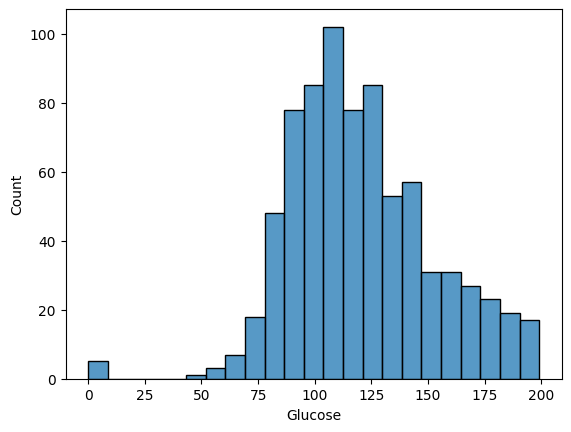

In [10]:
ax = sns.histplot(df["Glucose"])
plt.show() # Plot histogram to show distributions of dataset

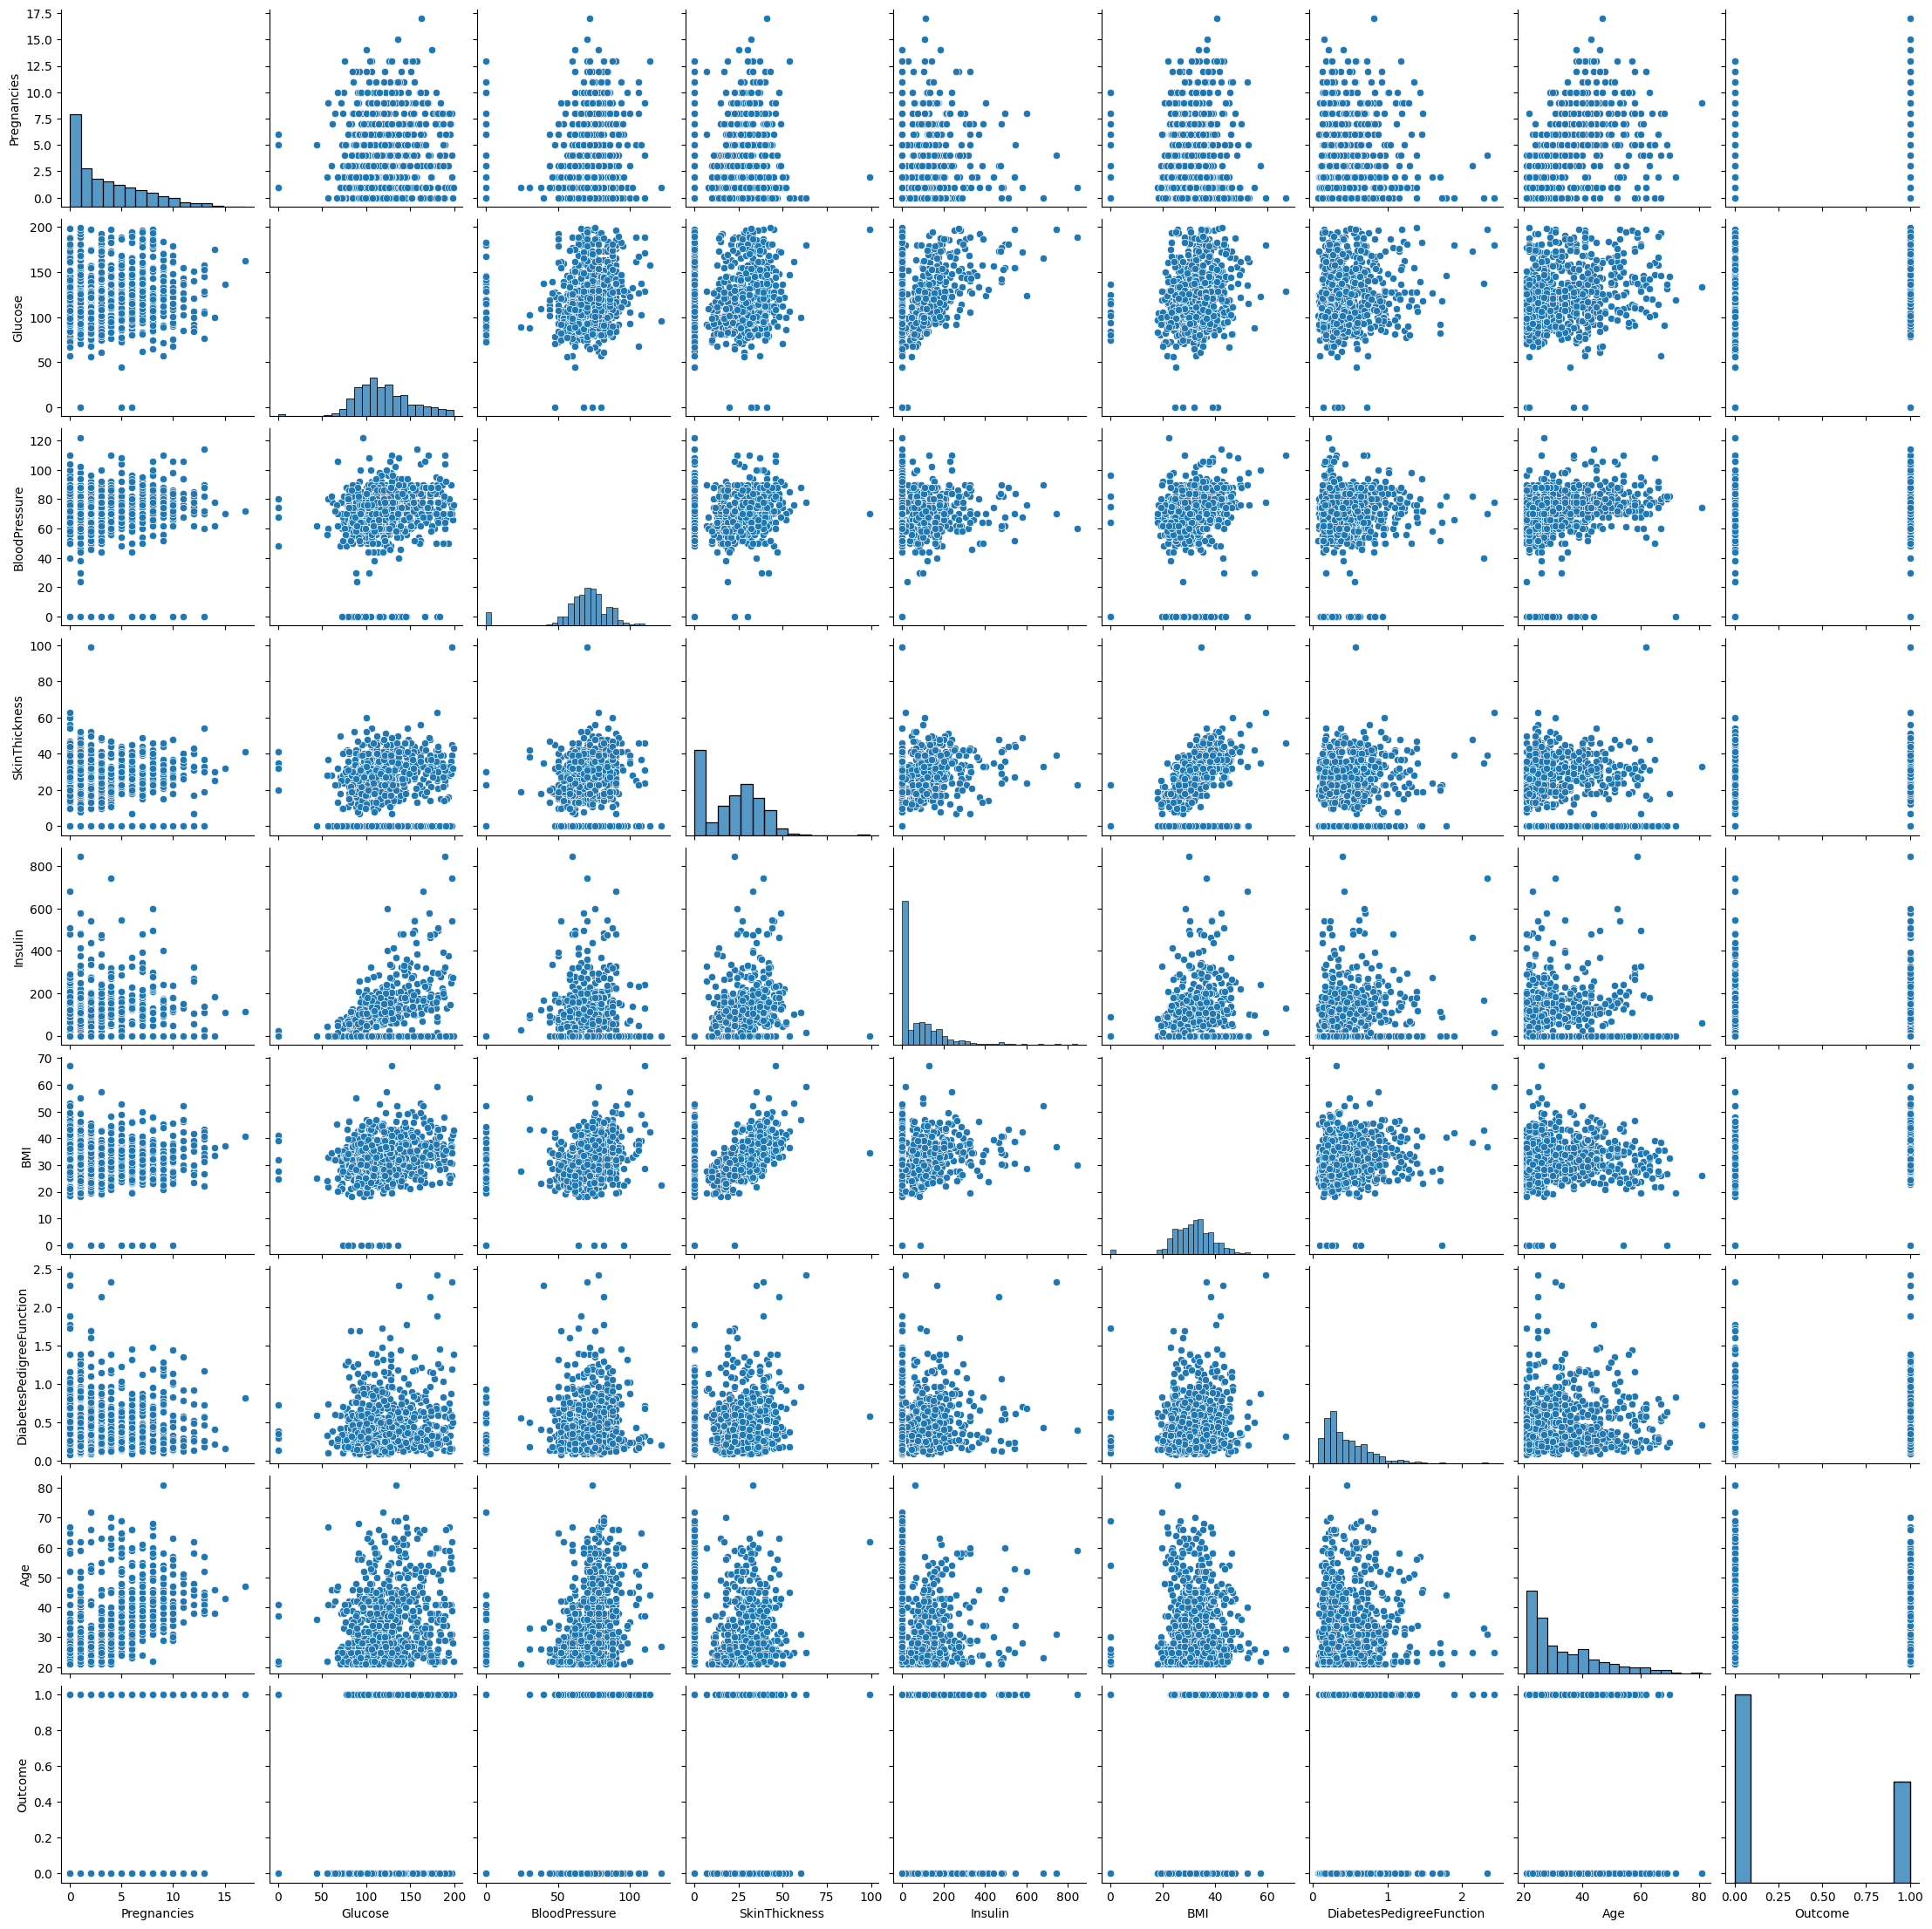

In [11]:
# pair plot to visulize pair-wise relationships to see how columns are related
sns.pairplot(df)

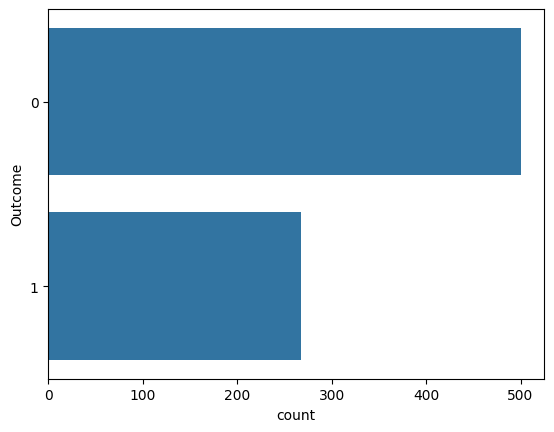

In [12]:
ax = sns.countplot(y="Outcome", data=df) # Method used to Show the counts of observations (distribution of the location)

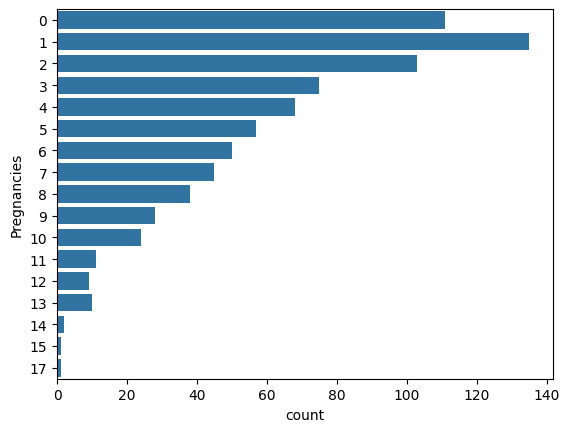

In [13]:
ax = sns.countplot(y="Pregnancies", data=df)

<Axes: xlabel='Age', ylabel='Glucose'>

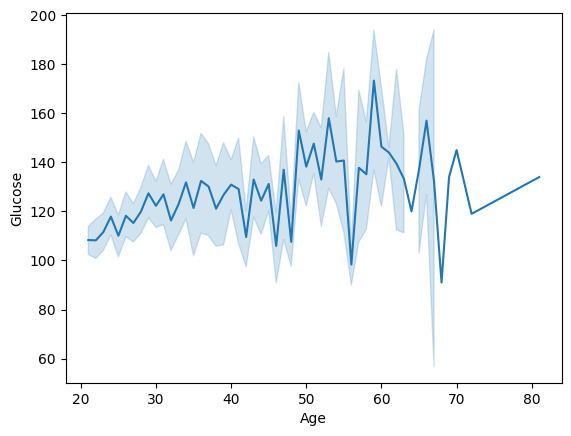

In [14]:
sns.lineplot(data=df, x="Age", y="Glucose") # plot to see the rent trend

In [15]:
# split dataset in features and target variable
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age','Glucose','BloodPressure','DiabetesPedigreeFunction']
X = df[feature_cols] # Features
y = df.Outcome # Target variable

In [16]:
# Split dataset into training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) 
# 70% training and 30% test

In [17]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
score=r2_score(y_test,y_pred)
print("The value of R squared is ",score)
print("The MSE is=",mean_squared_error(y_test,y_pred))
print("The RMSE value is=",np.sqrt(mean_squared_error(y_test,y_pred)))
score_data =score
report=classification_report(y_test,y_pred)
print(report)

Accuracy: 0.7705627705627706
The value of R squared is  0.013456889605157452
The MSE is= 0.22943722943722944
The RMSE value is= 0.4789960641145493
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       146
           1       0.71      0.64      0.67        85

    accuracy                           0.77       231
   macro avg       0.76      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231



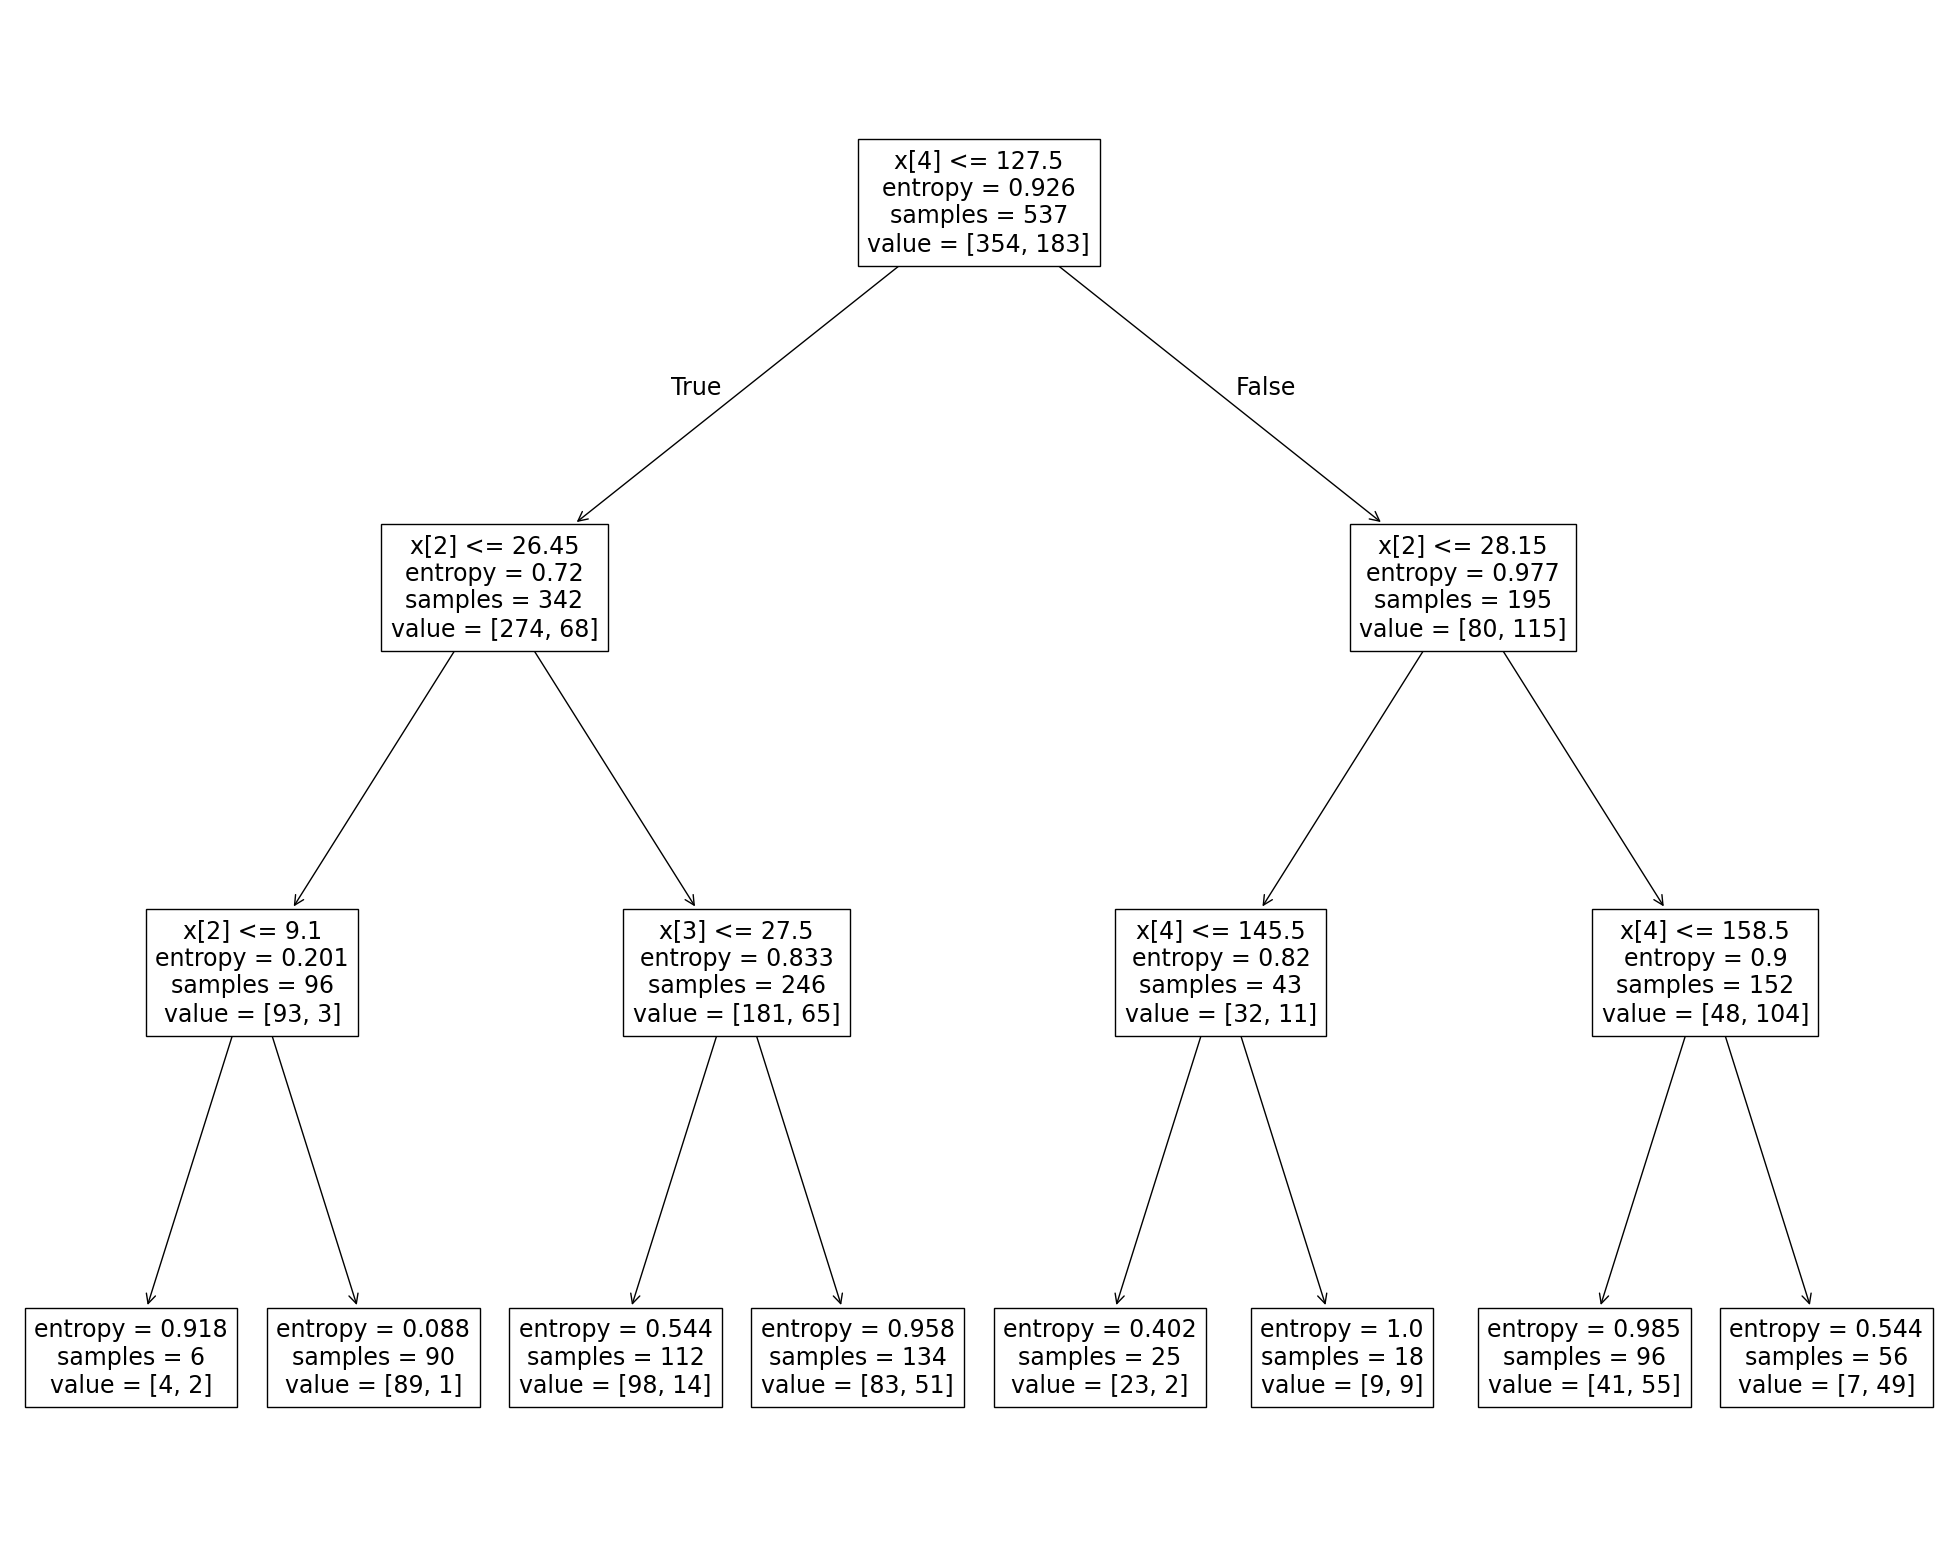

In [18]:
plt.figure(figsize=(25,20))
tree.plot_tree(clf)
plt.show()

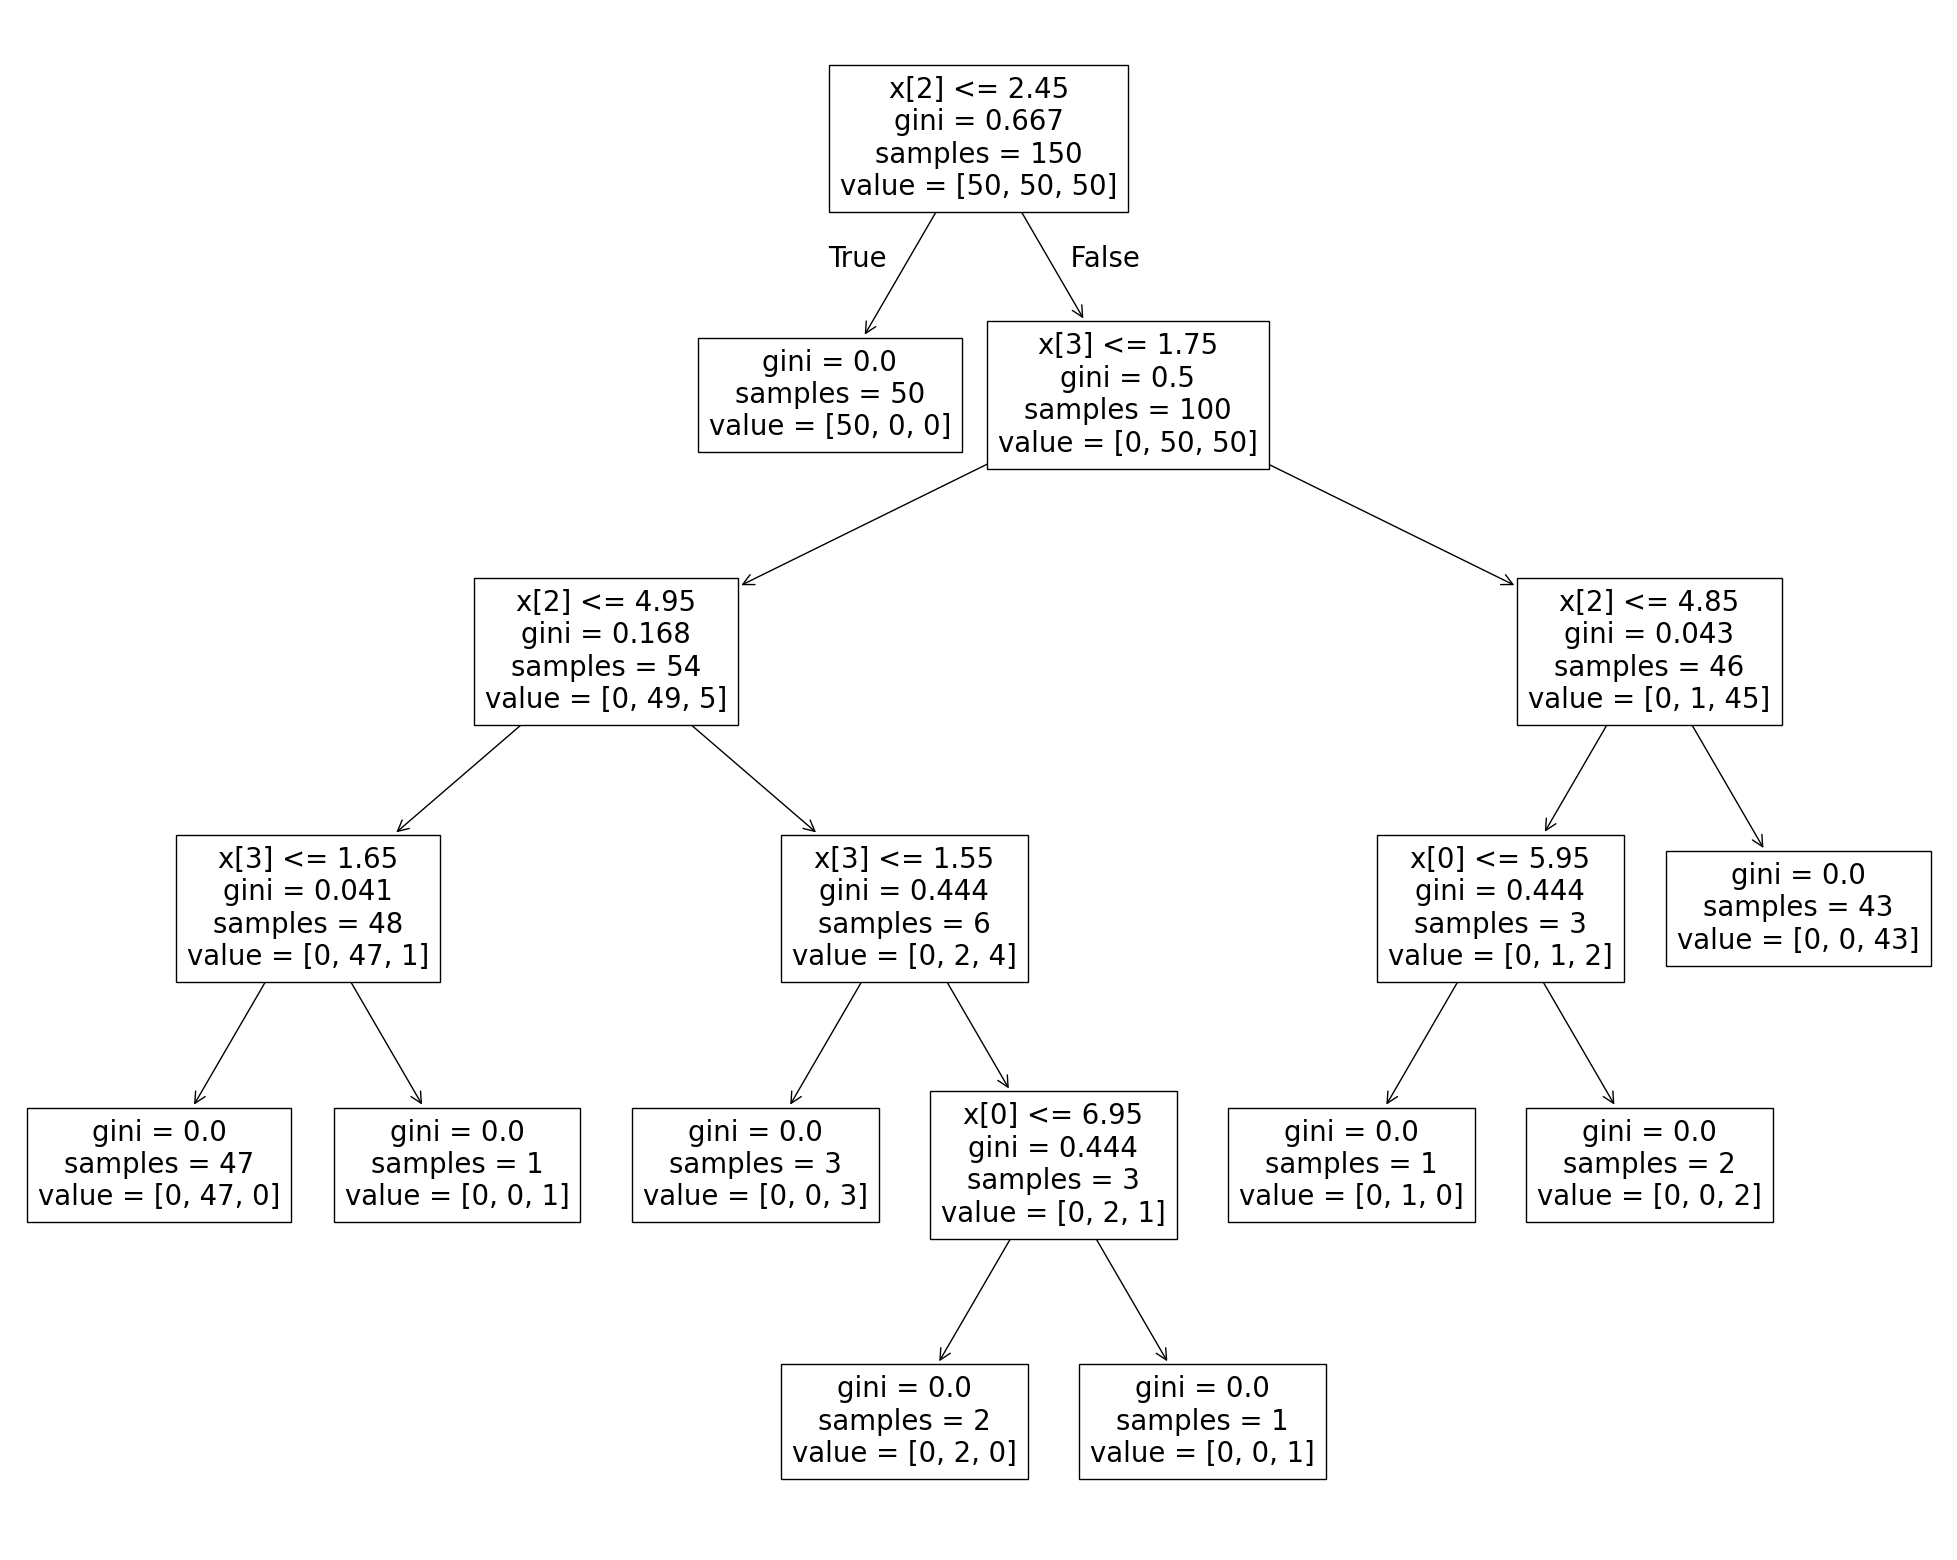

Accuracy: 0.7705627705627706
The value of R squared is  0.013456889605157452
The MSE is= 0.22943722943722944
The RMSE value is= 0.4789960641145493
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       146
           1       0.71      0.64      0.67        85

    accuracy                           0.77       231
   macro avg       0.76      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231

[[124  22]
 [ 31  54]]


In [19]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)
plt.figure(figsize=(25,20))
tree.plot_tree(clf)
plt.show()
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
score=r2_score(y_test,y_pred)
print("The value of R squared is ",score)
print("The MSE is=",mean_squared_error(y_test,y_pred))
print("The RMSE value is=",np.sqrt(mean_squared_error(y_test,y_pred)))
score1=score
report=classification_report(y_test,y_pred)
print(report)
mat=confusion_matrix(y_test, y_pred)
print(mat)

In [20]:
scores = pd.DataFrame()
scores['Dataset'] = ['Diabetes Dataset',"Iris Dataset"]
scores["Accuracy"] = [0.77*100,0.77*100]
scores.head()

,Dataset,Accuracy
0,Diabetes Dataset,77.0
1,Iris Dataset,77.0
